# D2C Customer Churn Intelligence
## Part 2 - RFM Segmentation & Retention Strategy

# 1. Environment Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully")

Libraries loaded successfully


# 2. Load Data

In [2]:
DATA_PATH = Path("../../data")

rfm = pd.read_csv(DATA_PATH / "rfm_modeling_snapshot.csv")
customers = pd.read_csv(DATA_PATH / "customers.csv")
labels = pd.read_csv(DATA_PATH / "churn_labels.csv")

print("Datasets loaded")

Datasets loaded


In [3]:
print("RFM Shape:", rfm.shape)
print("Customers Shape:", customers.shape)
print("Labels Shape:", labels.shape)

display(rfm.head())

RFM Shape: (2400, 29)
Customers Shape: (2400, 9)
Labels Shape: (2400, 4)


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


# 3. Data Preparation

## RFM Feature Exploration

In [4]:
rfm.columns.tolist()

['customer_id',
 'snapshot_date',
 'city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'marketing_consent',
 'recency_days',
 'frequency_180d',
 'monetary_180d',
 'return_rate_180d',
 'avg_discount_pct_180d',
 'avg_rating_180d',
 'category_diversity_180d',
 'ticket_count_90d',
 'negative_ticket_rate_90d',
 'avg_resolution_hours_90d',
 'days_since_signup',
 'sessions_30d',
 'product_views_30d',
 'cart_adds_30d',
 'wishlist_adds_30d',
 'abandoned_carts_30d',
 'email_opens_30d',
 'campaign_clicks_30d',
 'last_visit_days_ago',
 'churn_next_60d',
 'split']

In [5]:
rfm[
    [
        "customer_id",
        "recency_days",
        "frequency_180d",
        "monetary_180d"
    ]
].describe()

,recency_days,frequency_180d,monetary_180d
count,2400.000000,2400.000000,2400.000000
mean,87.375833,1.594583,1179.763196
std,80.137473,1.184964,1035.900649
min,0.000000,0.000000,0.000000
25%,25.000000,1.000000,449.270000
50%,66.000000,1.000000,911.875000
75%,129.000000,2.000000,1681.510000
max,562.000000,8.000000,6982.410000


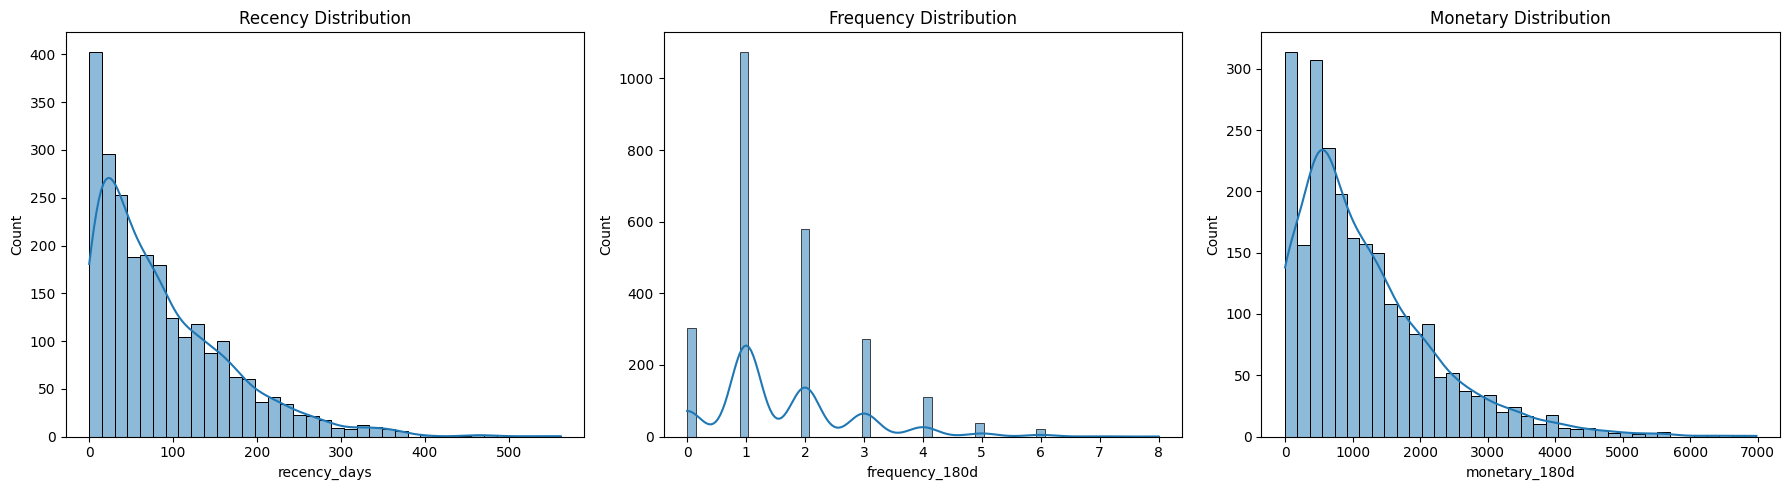

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    rfm["recency_days"],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Recency Distribution")

sns.histplot(
    rfm["frequency_180d"],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Frequency Distribution")

sns.histplot(
    rfm["monetary_180d"],
    kde=True,
    ax=axes[2]
)

axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [7]:
rfm[
    [
        "recency_days",
        "frequency_180d",
        "monetary_180d"
    ]
].quantile(
    [0.2, 0.4, 0.6, 0.8]
)

,recency_days,frequency_180d,monetary_180d
0.2,20.0,1.0,374.866
0.4,46.0,1.0,689.208
0.6,85.0,2.0,1181.688
0.8,147.2,2.0,1899.488


# 4. RFM Score Construction

## Recency Score

In [8]:
rfm["R_score"] = pd.qcut(
    rfm["recency_days"],
    q=5,
    labels=[5,4,3,2,1]
).astype(int)

rfm["R_score"].value_counts().sort_index()

R_score
1    480
2    471
3    488
4    461
5    500
Name: count, dtype: int64

## Frequency Score

In [9]:
rfm["F_score"] = np.select(
    [
        rfm["frequency_180d"] >= 5,
        rfm["frequency_180d"] >= 3,
        rfm["frequency_180d"] >= 2,
        rfm["frequency_180d"] >= 1
    ],
    [
        5,
        4,
        3,
        2
    ],
    default=1
)

rfm["F_score"].value_counts().sort_index()

F_score
1     302
2    1075
3     579
4     383
5      61
Name: count, dtype: int64

## Monetary Score

In [10]:
rfm["M_score"] = pd.qcut(
    rfm["monetary_180d"],
    q=5,
    labels=[1,2,3,4,5]
).astype(int)

rfm["M_score"].value_counts().sort_index()

M_score
1    480
2    480
3    480
4    480
5    480
Name: count, dtype: int64

## Create Combined RFM Score

In [11]:
rfm["RFM_score"] = (
    rfm["R_score"] +
    rfm["F_score"] +
    rfm["M_score"]
)

rfm[
    [
        "customer_id",
        "R_score",
        "F_score",
        "M_score",
        "RFM_score"
    ]
].head()

,customer_id,R_score,F_score,M_score,RFM_score
0,CUST00001,2,2,1,5
1,CUST00002,4,2,2,8
2,CUST00003,1,2,2,5
3,CUST00004,2,2,4,8
4,CUST00005,4,4,4,12


## Validate Score Distribution

In [12]:
rfm["RFM_score"].describe()

count    2400.000000
mean        8.523333
std         3.187531
min         3.000000
25%         6.000000
50%         9.000000
75%        11.000000
max        15.000000
Name: RFM_score, dtype: float64

## Visualize RFM Score

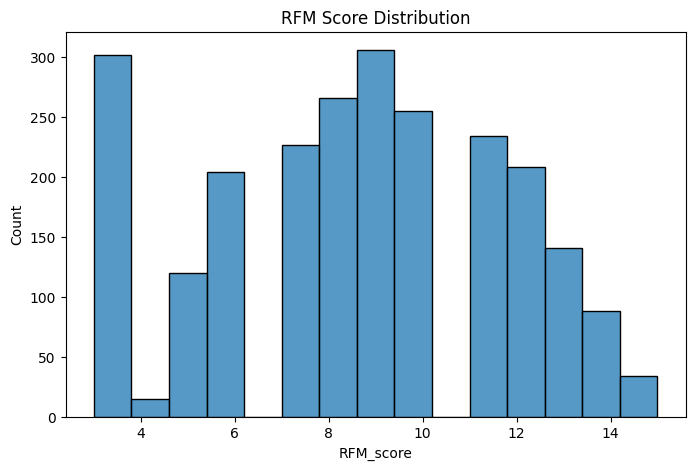

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["RFM_score"],
    bins=15
)

plt.title("RFM Score Distribution")

plt.show()

# 5. Customer Segment Creation

In [14]:
rfm["RFM_score"].value_counts().sort_index()

RFM_score
3     302
4      15
5     120
6     204
7     227
8     266
9     306
10    255
11    234
12    208
13    141
14     88
15     34
Name: count, dtype: int64

In [15]:
rfm[
    [
        "R_score",
        "F_score",
        "M_score"
    ]
].head()

,R_score,F_score,M_score
0,2,2,1
1,4,2,2
2,1,2,2
3,2,2,4
4,4,4,4


## Segment Creation Logic

In [16]:
def assign_segment(row):

    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]

    # Champions
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # Loyal Customers
    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"

    # Potential Loyalists
    elif r >= 4 and (f >= 2 or m >= 2):
        return "Potential Loyalists"

    # At Risk
    elif r <= 2 and (f >= 3 or m >= 3):
        return "At Risk"

    # Hibernating
    elif r <= 2 and f <= 2:
        return "Hibernating"

    else:
        return "Needs Attention"

## Apply Segments

In [17]:
rfm["segment"] = rfm.apply(
    assign_segment,
    axis=1
)

rfm["segment"].value_counts()

segment
Hibernating            553
Loyal Customers        523
Potential Loyalists    434
At Risk                398
Champions              260
Needs Attention        232
Name: count, dtype: int64

## Segment Distribution Chart

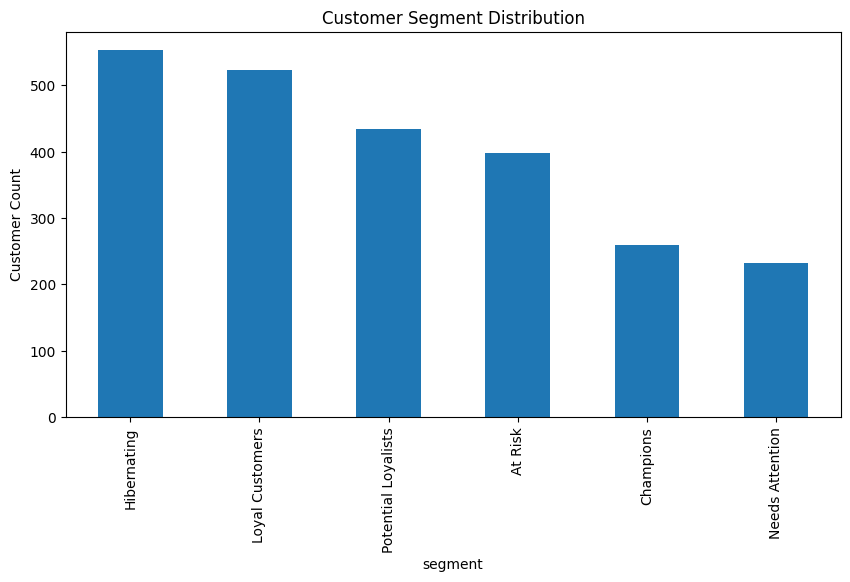

In [18]:
plt.figure(figsize=(10,5))

rfm["segment"]\
.value_counts()\
.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.ylabel("Customer Count")

plt.show()

In [19]:
rfm["segment"].value_counts()

segment
Hibernating            553
Loyal Customers        523
Potential Loyalists    434
At Risk                398
Champions              260
Needs Attention        232
Name: count, dtype: int64

# 6. Segment Profiling

## Segment Counts

In [20]:
segment_profile = rfm.groupby("segment").agg(
    {
        "recency_days": "mean",
        "frequency_180d": "mean",
        "monetary_180d": "mean",
        "RFM_score": "mean"
    }
).round(2)

segment_profile

,recency_days,frequency_180d,monetary_180d,RFM_score
segment,,,,
At Risk,124.63,1.78,1502.66,8.25
Champions,20.30,3.75,2765.39,13.47
Hibernating,195.85,0.45,207.40,4.09
Loyal Customers,42.52,2.31,1719.86,11.06
Needs Attention,66.58,1.02,760.96,7.45
Potential Loyalists,20.34,1.03,745.73,8.98


## Segment Sizes

In [21]:
(
    rfm["segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment
Hibernating            23.04
Loyal Customers        21.79
Potential Loyalists    18.08
At Risk                16.58
Champions              10.83
Needs Attention         9.67
Name: proportion, dtype: float64

## Heatmap

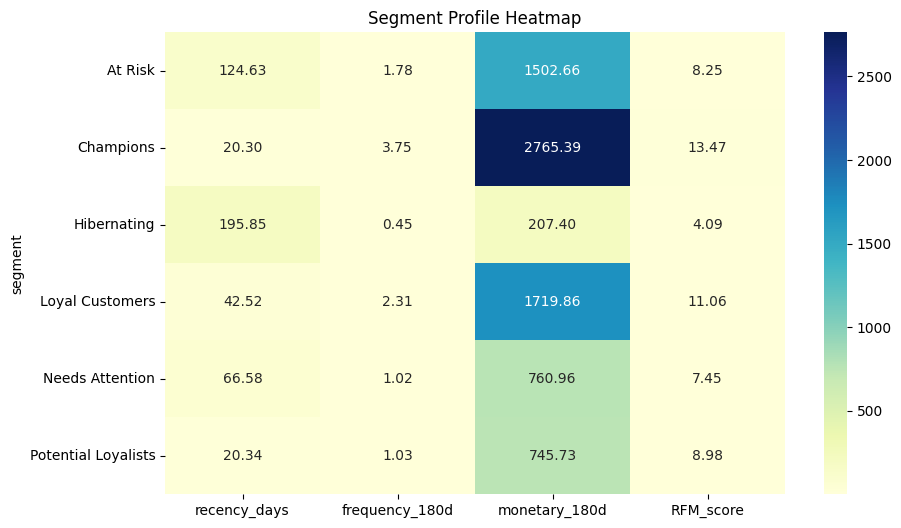

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(
    segment_profile,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Segment Profile Heatmap")

plt.show()

# 7. Retention Strategy Design

In [31]:
retention_actions = pd.DataFrame({
    "Segment": [
        "Champions",
        "Loyal Customers",
        "Potential Loyalists",
        "At Risk",
        "Needs Attention",
        "Hibernating"
    ],
    "Primary Goal": [
        "Protect",
        "Retain",
        "Develop",
        "Recover",
        "Monitor",
        "Reactivate"
    ],
    "Recommended Action": [
        "VIP rewards",
        "Loyalty incentives",
        "Cross-sell campaigns",
        "Win-back campaigns",
        "Engagement nudges",
        "Low-cost reactivation"
    ]
})

retention_actions

,Segment,Primary Goal,Recommended Action
0,Champions,Protect,VIP rewards
1,Loyal Customers,Retain,Loyalty incentives
2,Potential Loyalists,Develop,Cross-sell campaigns
3,At Risk,Recover,Win-back campaigns
4,Needs Attention,Monitor,Engagement nudges
5,Hibernating,Reactivate,Low-cost reactivation


# 8. Budget-Constrained Prioritization

In [24]:
priority_map = {
    "At Risk": 1,
    "Potential Loyalists": 2,
    "Loyal Customers": 3,
    "Champions": 4,
    "Needs Attention": 5,
    "Hibernating": 6
}

rfm["retention_priority"] = (
    rfm["segment"]
    .map(priority_map)
)

rfm[
    [
        "customer_id",
        "segment",
        "retention_priority"
    ]
].head()

,customer_id,segment,retention_priority
0,CUST00001,Hibernating,6
1,CUST00002,Potential Loyalists,2
2,CUST00003,Hibernating,6
3,CUST00004,At Risk,1
4,CUST00005,Champions,4


## Retention Prioritization Framework

## Priority Distribution

In [25]:
rfm.groupby("segment")[
    "retention_priority"
].first()

segment
At Risk                1
Champions              4
Hibernating            6
Loyal Customers        3
Needs Attention        5
Potential Loyalists    2
Name: retention_priority, dtype: int64

## Segment Counts

In [26]:
rfm["segment"].value_counts()

segment
Hibernating            553
Loyal Customers        523
Potential Loyalists    434
At Risk                398
Champions              260
Needs Attention        232
Name: count, dtype: int64

## Segment Visualization

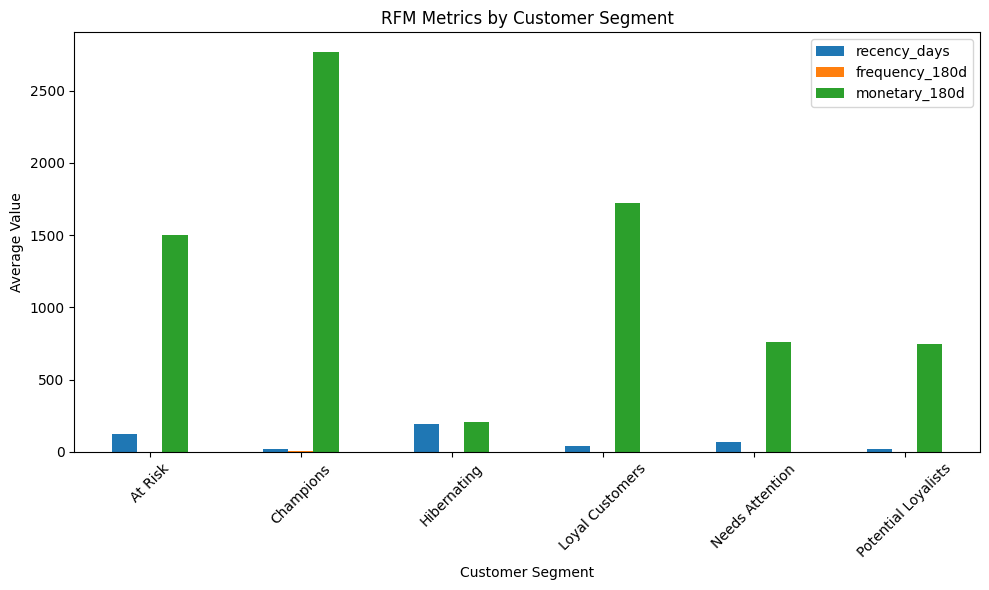

In [30]:
fig, ax = plt.subplots(figsize=(10,6))

segment_profile[
    ["recency_days","frequency_180d","monetary_180d"]
].plot(
    kind="bar",
    ax=ax
)

ax.set_title("RFM Metrics by Customer Segment")
ax.set_ylabel("Average Value")
ax.set_xlabel("Customer Segment")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../outputs/segment_profile_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 9. Export Outputs

## Export Profile

In [23]:
segment_profile.to_csv(
    "../outputs/segment_profile.csv"
)

## Export Customer Segments

In [27]:
segments_output = rfm[
    [
        "customer_id",
        "segment",
        "retention_priority",
        "R_score",
        "F_score",
        "M_score",
        "RFM_score"
    ]
]

segments_output.to_csv(
    "../outputs/segments.csv",
    index=False
)

print("segments.csv exported successfully")

segments.csv exported successfully


## Export Priority Customers

In [28]:
top_priority_customers = rfm[
    rfm["segment"] == "At Risk"
].sort_values(
    "monetary_180d",
    ascending=False
)

top_priority_customers.to_csv(
    "../outputs/top_priority_customers.csv",
    index=False
)

print("top_priority_customers.csv exported")

top_priority_customers.csv exported


# 10. Conclusion

Key Findings:

- Six customer segments were created using RFM analysis.
- The At Risk segment contains 398 customers with high historical value but declining engagement.
- Champions represent approximately 11% of customers and should be protected through loyalty initiatives.
- Hibernating customers show very low engagement and should receive only low-cost reactivation efforts.
- Under a constrained budget, At Risk and Potential Loyalists should be prioritized due to their expected retention ROI.